# DOI vs. eggwater — whole-brain functional connectivity (difference-in-differences)

This notebook implements the analysis plan for the DOI psychedelic experiment as a
**difference-in-differences (DiD)** design. The drug effect is the *difference of the
differences*:

$$\Delta\Delta = (\text{DOI}_{post}-\text{DOI}_{pre}) - (\text{eggwater}_{post}-\text{eggwater}_{pre})$$

The eggwater (vehicle) fish absorb everything that is *not* the drug — the injection
transient, the passage of time, photobleaching, arousal from the pulse. So every test
below targets the **group × epoch interaction**, not a bare pre/post change.

**Pipeline (the headline milestone is Sections 1–8):**

| # | Section | What it does |
|---|---------|--------------|
| 0 | Setup & config | imports, paths, all knobs in one dict |
| 1 | Load data | read the pack, join regions, assign DOI/eggwater groups |
| 2 | Epochs | pre / post windows with a transition buffer, matched length |
| 3 | Nodes | average neurons → region×time matrix; ΔF/F, detrend |
| 4 | FC estimation | Pearson (primary) + partial correlation (common-input control) |
| 5 | Thresholding | proportional threshold at *matched* density + density sweep |
| 6 | Graph measures | modularity, clustering, efficiency, participation, strength |
| 7 | Build dataset | one FC matrix + metric row per fish per epoch |
| 8 | DiD statistics | mixed model (group×epoch) + permutation + NBS on edges |
| 9 | Dynamic FC | sliding-window modularity trajectory |
| 10 | FC states | k-means state repertoire, dwell time, transition entropy |
| 11 | Entropy | activity / state-sequence entropy |
| 12 | Hub reorganization | centrality demotion under DOI |
| 13 | Signed modularity | Q⁺/Q⁻ using anticorrelations |
| 14 | Distance-dependence | does DOI add *long-range* edges (spatial integration)? |
| 15 | Effective connectivity | directed influence (Granger) — stretch aim |
| 16 | Neuron-level FC | distribution moments of neuron×neuron correlation |
| 17 | Onset trajectory | time-resolved DiD across the recording (drug kinetics) |
| 18 | Effective dimensionality | participation ratio of the covariance spectrum (threshold-free) |
| 19 | Criticality | neuronal avalanches + branching ratio |
| 20 | Metastability | SD of the Kuramoto order parameter (synchrony repertoire) |
| 21 | Structure–function | FC–SC decoupling (distance-proxy or real connectome) |

Each section is a set of small functions plus a run cell, so you can rerun any stage
in isolation and swap in your own choices.


## 0. Setup & configuration

Everything you might want to change lives in the `CFG` dict. Read the comments — the
defaults encode the design decisions from the plan (transition buffer, matched
windows, proportional thresholding at matched density, sweeping densities).

> **Kernel requirement:** the trace arrays were pickled under **numpy ≥ 2.0**, so this
> notebook must run in a numpy-2 kernel. The setup cell checks and stops early if not.

In [1]:
import sys, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as ss
from scipy import signal
import matplotlib.pyplot as plt

# hard requirement: traces are pickled under numpy>=2
_np_major = int(np.__version__.split('.')[0])
if _np_major < 2:
    raise RuntimeError(
        f"numpy {np.__version__} detected. The trace arrays in the pack were pickled "
        "under numpy>=2 and will not unpickle here. Switch to your numpy-2 kernel.")

# soft deps — used by later sections; import lazily but fail loudly with guidance
def _need(name):
    try:
        return __import__(name)
    except ImportError as e:
        raise ImportError(
            f"'{name}' is required for this section. Install it into this kernel "
            f"(e.g. `pip install {name}`).") from e

import networkx as nx
try:
    import sklearn  # noqa
except ImportError:
    warnings.warn("scikit-learn missing — Sections 10 (states) will not run.")
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except ImportError:
    warnings.warn("statsmodels missing — mixed-model stats in Section 8/12 will not run.")

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
print("numpy", np.__version__, "| pandas", pd.__version__, "| networkx", nx.__version__)


numpy 2.4.6 | pandas 3.0.3 | networkx 3.6.1


In [2]:
CFG = dict(
    # ---- data location -------------------------------------------------------
    pack_path = Path('/Volumes/Kobi/DOI_animals_good/temporal_pack_compact_clean.h5'),
    # 'raw_norm_temporal' = ΔF/F-like, min-max scaled to [0,1] per neuron; keeps BOTH
    #   activation AND suppression (below-baseline). PRIMARY input.
    # 'norm_temporal' = CaImAn deconvolved/denoised activity: non-negative, sparse,
    #   'activation-only' (suppression is rectified to ~0). It DISTORTS the correlation
    #   structure (inflates positive coupling) and hides regional suppression, so it is
    #   NOT the default. Use it only as a robustness pass and for effective connectivity
    #   (Sec 15), where a deconvolved trace reduces the calcium slow-kernel confound.
    # NB: min-max scaling is affine per neuron -> preserves Pearson correlation exactly,
    #   so raw_norm_temporal costs nothing for FC.
    trace_field = 'raw_norm_temporal',   # 'raw_norm_temporal' (primary) | 'norm_temporal' (deconvolved)

    # ---- epochs (Section 2) --------------------------------------------------
    # DOI has a pharmacokinetic onset and the injection makes a motion transient,
    # so we DROP a buffer right after the pulse before the 'post' window starts.
    post_buffer_frames = 60,   # frames to skip after the pulse (tune to your frame rate)
    pre_buffer_frames  = 10,   # frames to leave off the end of 'pre' (pre-injection settling)
    window_frames      = None, # None -> use the largest matched pre/post length available

    # ---- nodes / preprocessing (Section 3) -----------------------------------
    region_field   = 'single_region',   # per-neuron region label column
    min_neurons_per_region = 3,          # regions with fewer neurons are dropped for a fish
    region_prevalence = 0.5,             # a region must appear in >=50% of fish to enter REGION_SET
    # mapZebrain region MASKS (one .tif per region, in atlas-voxel space) — used for
    # anatomical region centroids (Sec 14/21). Filenames match `single_region` labels.
    # The ROI COMs in `atlas_voxel_mapzebrain` were registered into this same voxel frame
    # (2 transforms), so mask- and COM-derived coordinates are comparable. Set to None to
    # fall back to mean-ROI-COM centroids.
    region_mask_dir = Path('/Volumes/Kobi/DOI_animals_good/mapZebrain__regions__v2.0.1'),
    # raw_norm_temporal is ALREADY min-max normalized per neuron, so a median-baseline
    # ΔF/F on it is redundant (and not a true ΔF/F). Leave do_dff=False unless you feed
    # in genuinely raw fluorescence. For Pearson FC only `detrend` actually changes the
    # correlations (it removes the bleaching ramp that is confounded with time/drug);
    # do_dff and zscore are affine and leave Pearson correlations unchanged.
    do_dff       = False,                # ΔF/F (baseline=epoch median) — only for truly raw F
    detrend      = True,                 # linear detrend within each epoch (kills bleaching ramp)
    zscore       = True,                 # z-score each region trace within epoch

    # ---- FC + thresholding (Sections 4-5) ------------------------------------
    fc_method    = 'pearson',            # 'pearson' | 'partial'
    density      = 0.20,                 # proportional threshold: keep top 20% of |edges|
    density_sweep = (0.05, 0.10, 0.15, 0.20, 0.30),  # robustness sweep
    keep_sign    = True,                 # keep edge signs (needed for signed modularity)

    # ---- dynamics (Sections 9-10) --------------------------------------------
    win_len      = 60,   # sliding-window length (frames)
    win_step     = 10,   # sliding-window step (frames)
    n_states     = 4,    # k for FC-state clustering

    # ---- stats ---------------------------------------------------------------
    n_perm       = 2000, # permutations for the DiD permutation test / NBS
    rng_seed     = 0,
)
RNG = np.random.default_rng(CFG['rng_seed'])
CFG


{'pack_path': PosixPath('/Volumes/Kobi/DOI_animals_good/temporal_pack_compact_clean.h5'),
 'trace_field': 'raw_norm_temporal',
 'post_buffer_frames': 60,
 'pre_buffer_frames': 10,
 'window_frames': None,
 'region_field': 'single_region',
 'min_neurons_per_region': 3,
 'region_prevalence': 0.5,
 'region_mask_dir': PosixPath('/Volumes/Kobi/DOI_animals_good/mapZebrain__regions__v2.0.1'),
 'do_dff': False,
 'detrend': True,
 'zscore': True,
 'fc_method': 'pearson',
 'density': 0.2,
 'density_sweep': (0.05, 0.1, 0.15, 0.2, 0.3),
 'keep_sign': True,
 'win_len': 60,
 'win_step': 10,
 'n_states': 4,
 'n_perm': 2000,
 'rng_seed': 0}

## 1. Load the data & assign groups

We read `/compact_temporal` (traces + `pulse_frames` + `concentration`) and join
`/com_aligned` (`single_region`, 3-D `atlas_voxel_mapzebrain`). The **group** is derived
from `concentration`: `0.0` → *eggwater* (vehicle), `>0` → *DOI*.

Note each fish has its own recording length `T`, so FC is always computed *per fish*.

In [3]:
def load_pack(cfg):
    path = cfg['pack_path']
    if not path.is_file():
        raise FileNotFoundError(
            f"Pack not found at {path}. Edit CFG['pack_path'] to point at "
            "temporal_pack_compact_clean.h5 on your machine.")
    base = pd.read_hdf(path, key='compact_temporal')
    side = pd.read_hdf(path, key='com_aligned').set_index('pack_index')
    for c in ['com_aligned_mapzebrain', 'atlas_voxel_mapzebrain',
              'region_aligned_mapzebrain', 'single_region']:
        if c in side.columns:
            base[c] = side[c]
    # group label from concentration
    base['group'] = np.where(base['concentration'].astype(float) > 0, 'DOI', 'eggwater')
    return base

base = load_pack(CFG)
print("total ROIs:", len(base))
print(base[['fish_id','group','concentration']].drop_duplicates()
        .sort_values('fish_id').to_string(index=False))


total ROIs: 121950
 fish_id    group  concentration
       7 eggwater            0.0
       8 eggwater            0.0
       9 eggwater            0.0
      10 eggwater            0.0
      11 eggwater            0.0
      13      DOI           50.0
      15      DOI           50.0
      17      DOI           50.0
      20 eggwater            0.0
      21 eggwater            0.0
      24 eggwater            0.0
      28      DOI           50.0
      30      DOI           50.0
      31      DOI           50.0
      32      DOI           50.0


In [4]:
# per-fish summary: group, #neurons, pulse frame, #regions with enough cells
def fish_table(base, cfg):
    rows = []
    for fid, g in base.groupby('fish_id'):
        pf = g['pulse_frames'].iloc[0]
        pulse = int(pf[0]) if isinstance(pf, (list, tuple, np.ndarray)) and len(pf) else np.nan
        T = len(g[cfg['trace_field']].iloc[0])
        reg = g[cfg['region_field']].dropna()
        vc = reg.value_counts()
        good = vc[vc >= cfg['min_neurons_per_region']]
        rows.append(dict(fish_id=fid, group=g['group'].iloc[0],
                         concentration=float(g['concentration'].iloc[0]),
                         n_neurons=len(g), T=T, pulse=pulse,
                         n_regions=len(good)))
    return pd.DataFrame(rows).sort_values('fish_id').reset_index(drop=True)

FISH = fish_table(base, CFG)
FISH


,fish_id,group,concentration,n_neurons,T,pulse,n_regions
0,7,eggwater,0.0,4244,1606,292,34
1,8,eggwater,0.0,8230,1606,292,41
2,9,eggwater,0.0,8382,1606,292,42
3,10,eggwater,0.0,9725,1606,292,38
4,11,eggwater,0.0,6336,1606,292,35
5,13,DOI,50.0,8057,1606,292,36
6,15,DOI,50.0,8754,1606,292,37
7,17,DOI,50.0,6902,1606,292,38
8,20,eggwater,0.0,7691,1606,292,37
9,21,eggwater,0.0,6323,1606,292,35


## 2. Epoch definition (with transition buffer + matched length)

For a pulse at frame `p` and recording length `T`:

- **pre**  = `[p - L - pre_buffer, p - pre_buffer)`
- **post** = `[p + post_buffer, p + post_buffer + L)`

`post_buffer` discards the injection transient + drug onset. `L` (window length) is
matched between pre and post, and capped by whatever both sides can afford. Set
`CFG['window_frames']` to force a fixed `L` across all fish (recommended once you know
your shortest usable recording).

In [5]:
def define_epochs(pulse, T, cfg):
    pre_buf, post_buf = cfg['pre_buffer_frames'], cfg['post_buffer_frames']
    pre_end   = pulse - pre_buf
    post_start = pulse + post_buf
    max_pre  = pre_end                 # frames available before pulse (minus buffer)
    max_post = T - post_start          # frames available after buffer
    L = cfg['window_frames'] or min(max_pre, max_post)
    if L <= 0 or max_pre < L or max_post < L:
        return None  # not enough data on one side
    pre  = slice(pre_end - L, pre_end)
    post = slice(post_start, post_start + L)
    return dict(pre=pre, post=post, L=int(L))

# sanity check across fish
for _, r in FISH.iterrows():
    ep = define_epochs(int(r['pulse']), int(r['T']), CFG)
    print(f"fish {r['fish_id']:>2} ({r['group']:8s}) T={r['T']:5d} pulse={r['pulse']:5d} -> "
          + ("SKIP (too short)" if ep is None else
             f"pre[{ep['pre'].start}:{ep['pre'].stop}] post[{ep['post'].start}:{ep['post'].stop}] L={ep['L']}"))


fish  7 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish  8 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish  9 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 10 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 11 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 13 (DOI     ) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 15 (DOI     ) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 17 (DOI     ) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 20 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 21 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 24 (eggwater) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 28 (DOI     ) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 30 (DOI     ) T= 1606 pulse=  292 -> pre[0:282] post[352:634] L=282
fish 31 (DOI     ) T= 1606 pulse=  292 -> pre[0:282

## 3. Nodes = brain regions (mesoscale), with preprocessing

We average all neurons sharing a `single_region` label into one regional trace →
a **region × time** matrix per fish per epoch. This maps onto the psychedelic
literature and is where the integration/segregation hypothesis lives. (A neuron-level
second pass is a drop-in: skip the averaging and treat neurons as nodes.)

Preprocessing per epoch: (optional) ΔF/F, linear detrend to kill the bleaching ramp
(which is confounded with time-in-recording, hence with the drug), and z-score.
Detrending *within* each epoch is important so the post-window's drug-driven drift
isn't mistaken for signal or removed as trend inconsistently.

> **Which trace? `raw_norm_temporal`, not `norm_temporal`.** `norm_temporal` is a CaImAn
> deconvolved/denoised trace — non-negative, sparse, *activation-only* (measured on this
> data: per-neuron median ≈ 0.016, skew ≈ 3.5, ~8.5% hard zeros). It rectifies
> below-baseline dynamics, so **regional suppression is invisible** and the correlation
> structure is distorted (positive coupling inflated; anticorrelations degraded). Since
> suppression and anticorrelations are central to the integration/segregation and signed-
> modularity questions here, we default to `raw_norm_temporal` (ΔF/F-like, bidirectional).
> `norm_temporal` is reserved as a robustness pass and as the input to effective
> connectivity (Sec 15), where a deconvolved signal helpfully reduces the calcium
> slow-kernel autocorrelation. The min-max scaling both traces share is affine, so it
> preserves Pearson correlation exactly — `raw_norm_temporal` costs nothing.

In [6]:
def preprocess_trace(x, cfg):
    x = np.asarray(x, float)
    if cfg['do_dff']:
        base = np.median(x)
        base = base if abs(base) > 1e-9 else (np.mean(x) + 1e-9)
        x = (x - base) / base
    if cfg['detrend']:
        x = signal.detrend(x, type='linear')
    if cfg['zscore']:
        sd = x.std()
        x = (x - x.mean()) / sd if sd > 1e-9 else x - x.mean()
    return x

def region_matrix(fish_df, sl, regions, cfg):
    '''regions x time matrix for one fish/epoch, averaging neurons within a region.'''
    field, rfield = cfg['trace_field'], cfg['region_field']
    out = []
    for reg in regions:
        sub = fish_df[fish_df[rfield] == reg]
        if len(sub) < cfg['min_neurons_per_region']:
            out.append(np.full(sl.stop - sl.start, np.nan)); continue
        traces = np.vstack([np.asarray(t, float)[sl] for t in sub[field].values])
        reg_trace = np.nanmean(traces, axis=0)           # pool neurons first
        out.append(preprocess_trace(reg_trace, cfg))     # then preprocess the regional trace
    return np.vstack(out)   # (n_regions, L)


In [7]:
# Build REGION_SET: regions present (with enough neurons) in >= region_prevalence of fish.
def build_region_set(base, cfg):
    counts = {}
    fids = base['fish_id'].unique()
    for fid in fids:
        g = base[base['fish_id'] == fid]
        vc = g[cfg['region_field']].dropna().value_counts()
        for reg in vc[vc >= cfg['min_neurons_per_region']].index:
            counts[reg] = counts.get(reg, 0) + 1
    thresh = cfg['region_prevalence'] * len(fids)
    region_set = sorted([r for r, c in counts.items() if c >= thresh])
    return region_set

REGION_SET = build_region_set(base, CFG)
print(f"{len(REGION_SET)} regions in REGION_SET (>= {CFG['region_prevalence']:.0%} of fish):")
print(REGION_SET)


40 regions in REGION_SET (>= 50% of fish):
['abducens_motor_nucleus', 'anterior_(dorsal)_trigeminal_motor_nucleus', 'anterior_lateral_line_ganglion', 'caudal_hypothalamus', 'cerebellum', 'dorsal_medulla_oblongata', 'dorsal_telencephalon_(pallium)', 'eminentia_thalami', 'epiphysis', 'facial_motor_nucleus', 'habenula', 'inferior_olive', 'inferior_raphe', 'intermediate_hypothalamus_(entire)', 'interpeduncular_nucleus', 'locus_coeruleus', 'medial_octavolateralis_nucleus', 'nucleus_isthmi', 'oculomotor_nucleus', 'olfactory_bulb', 'olfactory_epithelium', 'periventricular_layer', 'posterior_(ventral)_trigeminal_motor_nucleus', 'posterior_lateral_line_ganglion', 'posterior_tuberculum_(basal_part_of_prethalamus_and_thalamus)', 'preoptic_region', 'pretectum', 'prethalamus_(ventral_thalamus)', 'retina', 'superior_raphe', 'tectal_neuropil', 'tegmentum', 'thalamus_(dorsal_thalamus)', 'torus_longitudinalis', 'torus_semicircularis', 'trigeminal_ganglion', 'vagal_sensory_lobe', 'vagus_motor_nucleus', 

## 4. FC estimation — Pearson (primary) + partial correlation

Zero-lag Pearson is the standard for zebrafish whole-brain FC and is the primary
measure. **Partial correlation** is the second estimator: it suppresses the
common-input problem, so a brain-wide arousal shift under DOI can't light up every
edge. Rows/cols that are all-NaN (a region the fish lacks) are kept as NaN so matrices
stay aligned to `REGION_SET`.

In [8]:
def pearson_fc(M):
    '''M: (n_regions, T) -> (n_regions, n_regions) correlation, NaN-safe.'''
    n = M.shape[0]
    C = np.full((n, n), np.nan)
    ok = ~np.all(np.isnan(M), axis=1)
    idx = np.where(ok)[0]
    if len(idx) < 2:
        return C
    sub = M[idx]
    Csub = np.corrcoef(sub)
    for a, i in enumerate(idx):
        for b, j in enumerate(idx):
            C[i, j] = Csub[a, b]
    return C

def partial_corr_fc(M, ridge=1e-3):
    '''Partial correlation via (regularized) precision matrix.'''
    n = M.shape[0]
    P = np.full((n, n), np.nan)
    ok = ~np.all(np.isnan(M), axis=1)
    idx = np.where(ok)[0]
    if len(idx) < 3:
        return P
    C = np.corrcoef(M[idx])
    C += ridge * np.eye(len(idx))
    prec = np.linalg.pinv(C)
    d = np.sqrt(np.outer(np.diag(prec), np.diag(prec)))
    Psub = -prec / d
    np.fill_diagonal(Psub, 1.0)
    for a, i in enumerate(idx):
        for b, j in enumerate(idx):
            P[i, j] = Psub[a, b]
    return P

def estimate_fc(M, cfg):
    return partial_corr_fc(M) if cfg['fc_method'] == 'partial' else pearson_fc(M)


## 5. Proportional thresholding at *matched* density

Threshold by keeping the top `density` fraction of edges **by |weight|**, matched
across all conditions. This is the trap-avoidance step: a raw difference in overall
correlation strength between DOI and eggwater must not masquerade as a topology change.
We also **sweep** densities so no conclusion rests on one cutoff.

In [9]:
def proportional_threshold(C, density, keep_sign=True):
    '''Keep the strongest `density` fraction of off-diagonal edges by |weight|.'''
    n = C.shape[0]
    A = np.zeros_like(C)
    iu = np.triu_indices(n, k=1)
    w = C[iu].copy()
    valid = ~np.isnan(w)
    if valid.sum() == 0:
        return A
    k = max(1, int(round(density * valid.sum())))
    order = np.argsort(-np.abs(np.where(valid, w, 0)))
    keep = order[:k]
    vals = w[keep] if keep_sign else np.abs(w[keep])
    ii, jj = iu[0][keep], iu[1][keep]
    A[ii, jj] = vals
    A[jj, ii] = vals
    return A


## 6. Graph measures (integration vs. segregation)

- **Segregation:** modularity `Q`, clustering coefficient.
- **Integration:** global efficiency, local efficiency.
- **Hubs / nodal:** participation coefficient, node strength/degree.
- **Signed:** `Q⁺/Q⁻` (Section 13) using anticorrelations.

Implemented on `networkx` + numpy (no `bctpy` dependency). Weighted metrics use
absolute weights where a metric needs non-negative weights; signs are used explicitly
only in the signed-modularity routine.

In [10]:
def _nx_from_matrix(A, absolute=True):
    W = np.abs(A) if absolute else A.copy()
    np.fill_diagonal(W, 0.0)
    G = nx.from_numpy_array(W)
    return G

def modularity_louvain(A, seed=0):
    G = _nx_from_matrix(A, absolute=True)
    if G.number_of_edges() == 0:
        return np.nan, {}
    comms = nx.community.louvain_communities(G, weight='weight', seed=seed)
    part = {n: ci for ci, c in enumerate(comms) for n in c}
    Q = nx.community.modularity(G, comms, weight='weight')
    return Q, part

def clustering_coef(A):
    G = _nx_from_matrix(A, absolute=True)
    if G.number_of_edges() == 0:
        return np.nan
    return np.mean(list(nx.clustering(G, weight='weight').values()))

def global_efficiency_w(A):
    G = _nx_from_matrix(A, absolute=True)
    if G.number_of_edges() == 0:
        return np.nan
    # distance = 1/weight; efficiency = mean inverse shortest path
    for u, v, d in G.edges(data=True):
        d['dist'] = 1.0 / d['weight'] if d['weight'] > 0 else np.inf
    n = G.number_of_nodes()
    eff = 0.0
    for src, lengths in nx.all_pairs_dijkstra_path_length(G, weight='dist'):
        for dst, dl in lengths.items():
            if dst != src and dl > 0:
                eff += 1.0 / dl
    return eff / (n * (n - 1)) if n > 1 else np.nan

def local_efficiency_w(A):
    G = _nx_from_matrix(A, absolute=True)
    effs = []
    for node in G.nodes():
        neigh = list(G.neighbors(node))
        if len(neigh) < 2:
            continue
        sub = A[np.ix_(neigh, neigh)]
        effs.append(global_efficiency_w(sub))
    return np.nanmean(effs) if effs else np.nan

def participation_coef(A, part):
    '''Participation coefficient per node given a community partition dict.'''
    W = np.abs(A); np.fill_diagonal(W, 0)
    n = W.shape[0]
    ki = W.sum(axis=1)
    comms = np.array([part.get(i, -1) for i in range(n)])
    P = np.zeros(n)
    for c in np.unique(comms):
        kis = W[:, comms == c].sum(axis=1)
        P += (kis / np.where(ki > 0, ki, 1)) ** 2
    P = 1 - P
    P[ki == 0] = 0
    return P

def node_strength(A):
    W = np.abs(A); np.fill_diagonal(W, 0)
    return W.sum(axis=1)

def signed_modularity(C, gamma=1.0, seed=0):
    '''Q+ / Q- signed modularity (Rubinov & Sporns 2011) on a signed matrix C.'''
    W = C.copy(); np.fill_diagonal(W, 0)
    W = np.nan_to_num(W)
    Wp, Wn = np.where(W > 0, W, 0.0), np.where(W < 0, -W, 0.0)
    # community from the positive graph
    G = _nx_from_matrix(Wp, absolute=True)
    if G.number_of_edges() == 0:
        return np.nan
    comms = nx.community.louvain_communities(G, weight='weight', seed=seed)
    ci = np.array([{n: k for k, c in enumerate(comms) for n in c}[i]
                   for i in range(W.shape[0])])
    def _q(Wx):
        s = Wx.sum()
        if s == 0:
            return 0.0
        k = Wx.sum(axis=1)
        B = Wx - gamma * np.outer(k, k) / s
        same = (ci[:, None] == ci[None, :])
        return (B * same).sum() / s
    sp, sn = Wp.sum(), Wn.sum()
    return _q(Wp) - (sn / (sp + sn)) * _q(Wn)

def graph_metrics(A):
    Q, part = modularity_louvain(A)
    return dict(modularity=Q,
                clustering=clustering_coef(A),
                global_eff=global_efficiency_w(A),
                local_eff=local_efficiency_w(A),
                mean_strength=float(np.nanmean(node_strength(A))),
                mean_participation=float(np.nanmean(participation_coef(A, part))))


## 7. Build the per-fish × epoch dataset — **the headline milestone**

For every fish and each epoch (pre/post) we build the region×time matrix, estimate FC,
threshold at matched density, and compute the graph metrics. The result is a tidy
table with one row per (fish, epoch) — ready for the DiD models. We also stash the
thresholded matrices for the edge-level (NBS) and dynamic analyses.

In [11]:
def build_dataset(base, cfg, regions):
    rows, mats = [], {}
    for fid in base['fish_id'].unique():
        g = base[base['fish_id'] == fid]
        pf = g['pulse_frames'].iloc[0]
        pulse = int(pf[0]) if isinstance(pf, (list, tuple, np.ndarray)) and len(pf) else None
        if pulse is None:
            continue
        T = len(g[cfg['trace_field']].iloc[0])
        ep = define_epochs(pulse, T, cfg)
        if ep is None:
            print(f"fish {fid}: skipped (recording too short for matched windows)"); continue
        group = g['group'].iloc[0]
        for epoch in ('pre', 'post'):
            M = region_matrix(g, ep[epoch], regions, cfg)
            C = estimate_fc(M, cfg)
            A = proportional_threshold(C, cfg['density'], cfg['keep_sign'])
            met = graph_metrics(A)
            met.update(fish_id=fid, group=group, epoch=epoch, L=ep['L'])
            rows.append(met)
            mats[(fid, epoch)] = dict(C=C, A=A, M=M)
    return pd.DataFrame(rows), mats

RESULTS, MATS = build_dataset(base, CFG, REGION_SET)
RESULTS[['fish_id','group','epoch','modularity','clustering',
         'global_eff','local_eff','mean_participation']].round(3)


,fish_id,group,epoch,modularity,clustering,global_eff,local_eff,mean_participation
0,7,eggwater,pre,0.147,0.357,0.155,0.650,0.242
1,7,eggwater,post,0.245,0.256,0.132,0.484,0.216
2,8,eggwater,pre,0.187,0.365,0.269,0.563,0.372
3,8,eggwater,post,0.165,0.377,0.250,0.549,0.318
4,9,eggwater,pre,0.282,0.325,0.218,0.570,0.112
5,9,eggwater,post,0.258,0.254,0.151,0.348,0.313
6,10,eggwater,pre,0.198,0.399,0.235,0.707,0.286
7,10,eggwater,post,0.129,0.368,0.208,0.684,0.214
8,11,eggwater,pre,0.221,0.379,0.229,0.708,0.082
9,11,eggwater,post,0.121,0.274,0.140,0.489,0.286


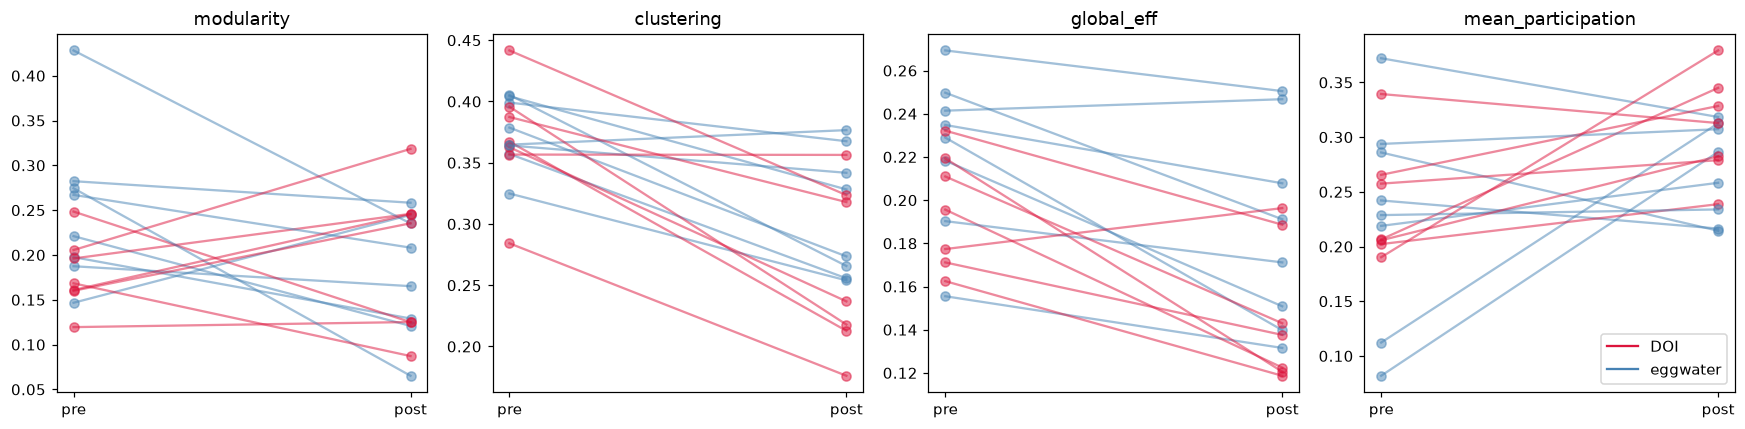

In [12]:
# Quick look: paired pre->post lines per fish, colored by group. This is the
# eyeball version of the DiD — do the DOI slopes differ from eggwater slopes?
metrics_to_plot = ['modularity', 'clustering', 'global_eff', 'mean_participation']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4*len(metrics_to_plot), 4))
colors = {'DOI': 'crimson', 'eggwater': 'steelblue'}
for ax, m in zip(axes, metrics_to_plot):
    for fid in RESULTS['fish_id'].unique():
        r = RESULTS[RESULTS.fish_id == fid]
        if set(r['epoch']) != {'pre', 'post'}:
            continue
        pre = r[r.epoch=='pre'][m].values[0]; post = r[r.epoch=='post'][m].values[0]
        grp = r['group'].values[0]
        ax.plot([0,1],[pre,post], '-o', color=colors[grp], alpha=0.5,
                label=grp)
    ax.set_xticks([0,1]); ax.set_xticklabels(['pre','post']); ax.set_title(m)
handles = [plt.Line2D([0],[0], color=c, label=g) for g,c in colors.items()]
axes[-1].legend(handles=handles); plt.tight_layout(); plt.show()


## 8. Difference-in-differences statistics

Two levels:

1. **Summary metrics → linear mixed-effects model** with fish as a random effect and a
   `group × epoch` interaction. The **interaction coefficient is the drug effect.**
2. **Permutation test** (shuffle group labels across fish) — assumption-light
   significance for the ΔΔ of any metric.
3. **Edges → Network-Based Statistic (NBS)** for the `group × epoch` interaction:
   *which connections* changed.

Headline question: does DOI (vs eggwater) **lower modularity & clustering** while
**raising efficiency**? Three numbers, one clean causal contrast.

In [13]:
def mixed_did(results, metric):
    '''LME: metric ~ group*epoch + (1|fish). Returns the interaction row.'''
    import statsmodels.formula.api as smf
    df = results.copy()
    df['epoch_post'] = (df['epoch'] == 'post').astype(int)
    df['grp_DOI'] = (df['group'] == 'DOI').astype(int)
    df = df.dropna(subset=[metric])
    md = smf.mixedlm(f"{metric} ~ grp_DOI * epoch_post", df, groups=df['fish_id'])
    fit = md.fit(reml=False)
    return fit

for m in ['modularity','clustering','global_eff','local_eff','mean_participation']:
    try:
        fit = mixed_did(RESULTS, m)
        coef = fit.params.get('grp_DOI:epoch_post', np.nan)
        p    = fit.pvalues.get('grp_DOI:epoch_post', np.nan)
        print(f"{m:20s}  interaction ΔΔ = {coef:+.4f}   p = {p:.4f}")
    except Exception as e:
        print(f"{m:20s}  (model failed: {e})")


modularity            interaction ΔΔ = +0.0899   p = 0.0480
clustering            interaction ΔΔ = -0.0408   p = 0.1175
global_eff            interaction ΔΔ = -0.0115   p = 0.4849
local_eff             interaction ΔΔ = -0.1407   p = 0.0098
mean_participation    interaction ΔΔ = +0.0322   p = 0.4606


/opt/anaconda3/envs/fc/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/fc/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/fc/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/fc/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/fc/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: T

In [14]:
def did_value(results, metric):
    '''(DOI post-pre) - (eggwater post-pre) using fish-averaged epoch means.'''
    def grp_delta(grp):
        d = results[results.group == grp]
        pre  = d[d.epoch=='pre'].groupby('fish_id')[metric].mean()
        post = d[d.epoch=='post'].groupby('fish_id')[metric].mean()
        return (post - pre).mean()
    return grp_delta('DOI') - grp_delta('eggwater')

def perm_test_did(results, metric, n_perm, rng):
    '''Shuffle group labels across fish; null distribution of the ΔΔ.'''
    obs = did_value(results, metric)
    fish_groups = results[['fish_id','group']].drop_duplicates().set_index('fish_id')['group']
    fids = fish_groups.index.values
    labels = fish_groups.values.copy()
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(labels)
        mapping = dict(zip(fids, perm))
        rr = results.copy()
        rr['group'] = rr['fish_id'].map(mapping)
        null[i] = did_value(rr, metric)
    p = (np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return obs, p, null

for m in ['modularity','clustering','global_eff','mean_participation']:
    obs, p, _ = perm_test_did(RESULTS, m, CFG['n_perm'], RNG)
    print(f"{m:20s}  ΔΔ = {obs:+.4f}   perm p = {p:.4f}")


modularity            ΔΔ = +0.0899   perm p = 0.0855
clustering            ΔΔ = -0.0408   perm p = 0.1619
global_eff            ΔΔ = -0.0115   perm p = 0.5282
mean_participation    ΔΔ = +0.0322   perm p = 0.5092


 density  DiD_modularity
    0.05        0.041873
    0.10        0.044020
    0.15        0.077746
    0.20        0.089944
    0.30        0.056593


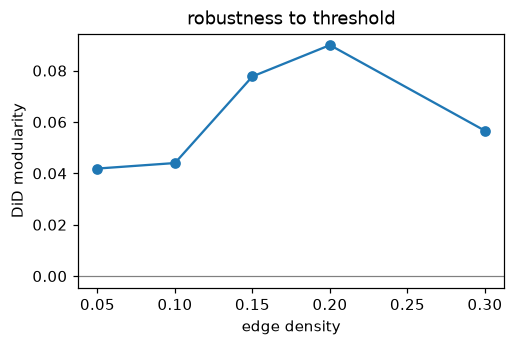

In [15]:
# Density sweep — confirm the modularity/efficiency effect is not a threshold artifact.
def sweep_density(base, cfg, regions, densities, metric='modularity'):
    out = []
    for dens in densities:
        c = dict(cfg); c['density'] = dens
        res, _ = build_dataset(base, c, regions)
        out.append((dens, did_value(res, metric)))
    return pd.DataFrame(out, columns=['density', f'DiD_{metric}'])

sweep = sweep_density(base, CFG, REGION_SET, CFG['density_sweep'], 'modularity')
print(sweep.to_string(index=False))
plt.figure(figsize=(5,3))
plt.axhline(0, color='gray', lw=0.8)
plt.plot(sweep['density'], sweep['DiD_modularity'], '-o')
plt.xlabel('edge density'); plt.ylabel('DiD modularity'); plt.title('robustness to threshold'); plt.show()


In [16]:
def nbs_interaction(mats, regions, n_perm, rng, edge_thresh=2.0):
    '''Network-Based Statistic on the group x epoch interaction.

    Per edge: DiD statistic = two-sample t of (post-pre) between DOI and eggwater.
    Suprathreshold edges -> connected components -> component-size significance vs a
    label-permutation null. Returns (component_masks, pvalues, edge_t).'''
    fids = sorted(set(f for f, _ in mats))
    n = len(regions)
    # per-fish edge difference vectors
    def edge_diff(fid):
        A_pre  = mats[(fid,'pre')]['C']; A_post = mats[(fid,'post')]['C']
        iu = np.triu_indices(n, 1)
        return (A_post - A_pre)[iu]
    groups = {f: MATS[(f,'pre')] and None for f in fids}  # placeholder
    grp_of = {f: RESULTS[RESULTS.fish_id==f]['group'].iloc[0] for f in fids}
    D = np.vstack([edge_diff(f) for f in fids])           # fish x edges
    g = np.array([grp_of[f]=='DOI' for f in fids])
    def edge_stat(mask):
        a = D[mask]; b = D[~mask]
        with np.errstate(invalid='ignore'):
            t = (np.nanmean(a,0)-np.nanmean(b,0)) / np.sqrt(
                np.nanvar(a,0,ddof=1)/max(mask.sum(),1) +
                np.nanvar(b,0,ddof=1)/max((~mask).sum(),1) + 1e-12)
        return np.nan_to_num(t)
    t_obs = edge_stat(g)
    def components(tvec):
        iu = np.triu_indices(n,1)
        supra = np.abs(tvec) > edge_thresh
        G = nx.Graph(); G.add_nodes_from(range(n))
        for e in np.where(supra)[0]:
            G.add_edge(iu[0][e], iu[1][e])
        return [c for c in nx.connected_components(G) if len(c) > 1]
    obs_comps = components(t_obs)
    obs_sizes = sorted([len(c) for c in obs_comps], reverse=True)
    null_max = np.zeros(n_perm)
    for i in range(n_perm):
        gp = rng.permutation(g)
        cc = components(edge_stat(gp))
        null_max[i] = max([len(c) for c in cc], default=0)
    pvals = [ (np.sum(null_max >= s)+1)/(n_perm+1) for s in obs_sizes ]
    return obs_comps, obs_sizes, pvals, t_obs

try:
    comps, sizes, pvals, t_edges = nbs_interaction(MATS, REGION_SET, min(CFG['n_perm'],1000), RNG)
    print("NBS components (size, p):")
    for c, s, p in zip(comps, sizes, pvals):
        print(f"  size={s:3d}  p={p:.4f}  regions={[REGION_SET[i] for i in sorted(c)]}")
    if not comps:
        print("  no suprathreshold components (try lowering edge_thresh)")
except Exception as e:
    print("NBS failed:", e)


/var/folders/5s/q3x21d8j6jvcnr7nmcb5xkwr0000gn/T/ipykernel_59244/4239609414.py:22: RuntimeWarning: Degrees of freedom <= 0 for slice.
  np.nanvar(a,0,ddof=1)/max(mask.sum(),1) +
/var/folders/5s/q3x21d8j6jvcnr7nmcb5xkwr0000gn/T/ipykernel_59244/4239609414.py:23: RuntimeWarning: Degrees of freedom <= 0 for slice.
  np.nanvar(b,0,ddof=1)/max((~mask).sum(),1) + 1e-12)
/var/folders/5s/q3x21d8j6jvcnr7nmcb5xkwr0000gn/T/ipykernel_59244/4239609414.py:21: RuntimeWarning: Mean of empty slice
  t = (np.nanmean(a,0)-np.nanmean(b,0)) / np.sqrt(


NBS components (size, p):
  size= 38  p=0.5624  regions=['abducens_motor_nucleus', 'anterior_(dorsal)_trigeminal_motor_nucleus', 'anterior_lateral_line_ganglion', 'caudal_hypothalamus', 'cerebellum', 'dorsal_medulla_oblongata', 'dorsal_telencephalon_(pallium)', 'eminentia_thalami', 'epiphysis', 'facial_motor_nucleus', 'habenula', 'inferior_olive', 'inferior_raphe', 'intermediate_hypothalamus_(entire)', 'interpeduncular_nucleus', 'locus_coeruleus', 'medial_octavolateralis_nucleus', 'nucleus_isthmi', 'oculomotor_nucleus', 'olfactory_bulb', 'olfactory_epithelium', 'periventricular_layer', 'posterior_(ventral)_trigeminal_motor_nucleus', 'posterior_lateral_line_ganglion', 'posterior_tuberculum_(basal_part_of_prethalamus_and_thalamus)', 'preoptic_region', 'pretectum', 'prethalamus_(ventral_thalamus)', 'retina', 'superior_raphe', 'tectal_neuropil', 'tegmentum', 'thalamus_(dorsal_thalamus)', 'torus_semicircularis', 'trigeminal_ganglion', 'vagus_motor_nucleus', 'ventral_medulla_oblongata', 'ven

## 9. Dynamic (time-resolved) FC

Slide a window across the whole recording, compute FC per window, and track modularity
over time. A drug effect *emerges and evolves*; this shows *when* modularity starts to
drop relative to eggwater. The pulse is marked; the post-buffer shading is the
transition we exclude from the static analysis.

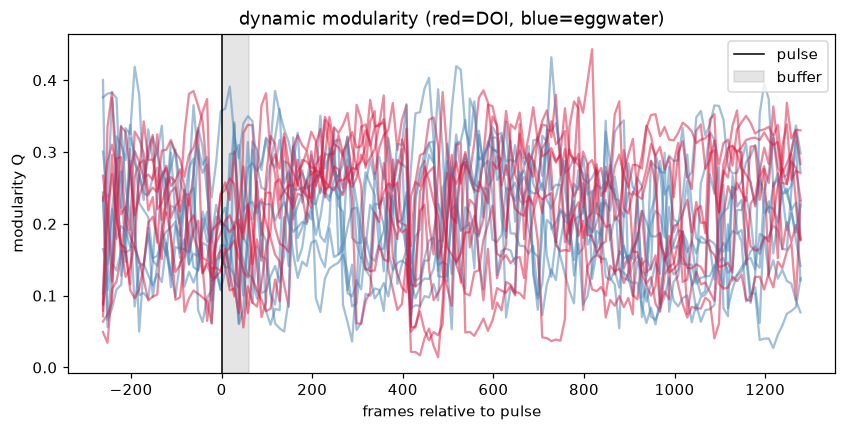

In [17]:
def sliding_modularity(base, fid, cfg, regions):
    g = base[base['fish_id'] == fid]
    T = len(g[cfg['trace_field']].iloc[0])
    # full-length region traces (preprocess on the whole recording here)
    full = region_matrix(g, slice(0, T), regions, cfg)
    wl, st = cfg['win_len'], cfg['win_step']
    centers, Qs = [], []
    for s in range(0, T - wl + 1, st):
        C = estimate_fc(full[:, s:s+wl], cfg)
        A = proportional_threshold(C, cfg['density'], cfg['keep_sign'])
        Q, _ = modularity_louvain(A)
        centers.append(s + wl//2); Qs.append(Q)
    return np.array(centers), np.array(Qs)

plt.figure(figsize=(9,4))
for fid in FISH['fish_id']:
    g = base[base['fish_id']==fid]
    pf = g['pulse_frames'].iloc[0]
    pulse = int(pf[0]) if len(pf) else None
    try:
        c, q = sliding_modularity(base, fid, CFG, REGION_SET)
    except Exception:
        continue
    grp = g['group'].iloc[0]
    plt.plot(c - (pulse or 0), q, color=('crimson' if grp=='DOI' else 'steelblue'),
             alpha=0.5)
plt.axvline(0, color='k', lw=1, label='pulse')
plt.axvspan(0, CFG['post_buffer_frames'], color='gray', alpha=0.2, label='buffer')
plt.xlabel('frames relative to pulse'); plt.ylabel('modularity Q')
plt.title('dynamic modularity (red=DOI, blue=eggwater)'); plt.legend(); plt.show()


## 10. FC states (dynamic repertoire)

Cluster the windowed FC matrices into recurring **states** (k-means on vectorized upper
triangles). Then ask whether DOI changes the repertoire: number of states visited,
dwell times, and **transition entropy**. Psilocybin work frames drug effects exactly as
shifts in the dynamic-state repertoire.

In [18]:
def windowed_fc_vectors(base, fid, cfg, regions):
    g = base[base['fish_id']==fid]
    T = len(g[cfg['trace_field']].iloc[0])
    full = region_matrix(g, slice(0,T), regions, cfg)
    wl, st = cfg['win_len'], cfg['win_step']
    iu = np.triu_indices(len(regions), 1)
    vecs, centers = [], []
    for s in range(0, T-wl+1, st):
        C = estimate_fc(full[:, s:s+wl], cfg)
        v = C[iu]
        vecs.append(np.nan_to_num(v)); centers.append(s+wl//2)
    return np.array(vecs), np.array(centers), T

def _kmeans_labels(X, k, seed):
    '''KMeans via sklearn if present, else a small numpy k-means++ fallback.'''
    try:
        from sklearn.cluster import KMeans
        return KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X).labels_
    except ImportError:
        rng = np.random.default_rng(seed)
        # k-means++ init
        cent = [X[rng.integers(len(X))]]
        for _ in range(1, k):
            d2 = np.min([((X - c) ** 2).sum(1) for c in cent], axis=0)
            cent.append(X[rng.choice(len(X), p=d2 / d2.sum())])
        cent = np.array(cent)
        for _ in range(100):
            lab = np.argmin(((X[:, None, :] - cent[None]) ** 2).sum(2), axis=1)
            new = np.array([X[lab == j].mean(0) if np.any(lab == j) else cent[j]
                            for j in range(k)])
            if np.allclose(new, cent):
                break
            cent = new
        return lab

def state_analysis(base, cfg, regions):
    allv, meta = [], []
    for fid in base['fish_id'].unique():
        g = base[base['fish_id']==fid]
        pf = g['pulse_frames'].iloc[0]; pulse = int(pf[0]) if len(pf) else None
        try:
            v, c, T = windowed_fc_vectors(base, fid, cfg, regions)
        except Exception:
            continue
        for vi, ci in zip(v, c):
            allv.append(vi); meta.append((fid, g['group'].iloc[0], ci, pulse))
    allv = np.array(allv)
    labels = _kmeans_labels(allv, cfg['n_states'], cfg['rng_seed'])
    meta = pd.DataFrame(meta, columns=['fish_id','group','center','pulse'])
    meta['state'] = labels
    meta['epoch'] = np.where(meta['center'] < meta['pulse'], 'pre', 'post')
    return meta

def transition_entropy(states):
    states = np.asarray(states); k = states.max()+1
    Tm = np.zeros((k,k))
    for a,b in zip(states[:-1], states[1:]):
        Tm[a,b]+=1
    Tm = Tm / np.where(Tm.sum(1,keepdims=True)>0, Tm.sum(1,keepdims=True), 1)
    ent=[]
    for row in Tm:
        p=row[row>0]; ent.append(-(p*np.log2(p)).sum())
    return float(np.mean(ent))

try:
    STATE_META = state_analysis(base, CFG, REGION_SET)
    # dwell fraction per state x group x epoch
    dwell = (STATE_META.groupby(['group','epoch','state']).size()
             / STATE_META.groupby(['group','epoch']).size()).unstack(fill_value=0)
    print("Dwell fraction (rows: group,epoch):\n", dwell.round(3))
    # transition entropy DiD
    rows=[]
    for (fid,grp), d in STATE_META.groupby(['fish_id','group']):
        for epoch in ['pre','post']:
            s = d[d.epoch==epoch].sort_values('center')['state'].values
            if len(s) > 3:
                rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                                 trans_entropy=transition_entropy(s)))
    ent_df = pd.DataFrame(rows)
    print("\nTransition-entropy ΔΔ =", round(did_value(ent_df,'trans_entropy'),4))
except Exception as e:
    print("state analysis failed:", e)


Dwell fraction (rows: group,epoch):
 state               0      1      2      3
group    epoch                            
DOI      post   0.141  0.346  0.000  0.513
         pre    0.249  0.466  0.000  0.286
eggwater post   0.178  0.442  0.116  0.264
         pre    0.222  0.528  0.120  0.130

Transition-entropy ΔΔ = -0.1714


## 11. Entropy measures

Increased entropy/randomness is one of the most consistent macroscale signatures of
psychedelics — a natural cross-check on the modularity story. We compute a simple
per-region activity entropy (histogram of ΔF/F values) averaged over regions, per
epoch, and take the DiD.

In [19]:
def activity_entropy(M, bins=32):
    '''mean Shannon entropy of per-region amplitude distributions.'''
    ents=[]
    for row in M:
        row = row[~np.isnan(row)]
        if len(row) < bins:
            continue
        h,_ = np.histogram(row, bins=bins, density=False)
        p = h/h.sum(); p = p[p>0]
        ents.append(-(p*np.log2(p)).sum())
    return float(np.mean(ents)) if ents else np.nan

ent_rows=[]
for (fid,epoch),d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    ent_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                         act_entropy=activity_entropy(d['M'])))
ENT = pd.DataFrame(ent_rows)
print("activity-entropy ΔΔ =", round(did_value(ENT,'act_entropy'),4))
obs,p,_ = perm_test_did(ENT,'act_entropy',CFG['n_perm'],RNG)
print(f"perm p = {p:.4f}")


activity-entropy ΔΔ = -0.0074
perm p = 0.9365


## 12. Hub reorganization

Human finding: dominant hubs *lose dominance* under psychedelics. Compute a centrality
(here: node strength + eigenvector centrality) per region pre/post, then test per-region
whether DOI demotes the usually-high-centrality hubs (DiD on centrality, ranked by
baseline centrality).

In [20]:
def eigenvector_centrality_robust(A):
    '''Eigenvector centrality that is well-defined on disconnected graphs.

    nx.eigenvector_centrality_numpy raises AmbiguousSolution when the graph is
    fragmented (our thresholded FC matrices have ~10 components / ~9 isolates).
    Instead we solve the Perron eigenvector *within each connected component*
    (np.linalg.eigh on the |weight| submatrix), scaling each component's
    unit-norm leading eigenvector by that component's leading eigenvalue so
    scores are comparable across components. Isolated nodes get 0.'''
    W = np.abs(np.asarray(A, float)); np.fill_diagonal(W, 0.0)
    n = W.shape[0]; cent = np.zeros(n)
    Gr = nx.from_numpy_array(W)
    for comp in nx.connected_components(Gr):
        nodes = sorted(comp)
        if len(nodes) < 2:
            continue                      # isolated node -> centrality 0
        sub = W[np.ix_(nodes, nodes)]
        vals, vecs = np.linalg.eigh(sub)  # symmetric -> real spectrum
        lead = np.abs(vecs[:, -1])        # Perron vector (sign-fixed positive)
        nrm = np.linalg.norm(lead)
        if nrm > 0:
            lead = lead / nrm
        cent[nodes] = lead * vals[-1]     # scale by component leading eigenvalue
    return cent

def nodal_centrality(A):
    return eigenvector_centrality_robust(A), node_strength(A)

cent_rows=[]
for (fid,epoch),d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    eig, strg = nodal_centrality(d['A'])
    for ri, reg in enumerate(REGION_SET):
        cent_rows.append(dict(fish_id=fid, group=grp, epoch=epoch, region=reg,
                              eig=eig[ri], strength=strg[ri]))
CENT = pd.DataFrame(cent_rows)

# baseline (eggwater pre) hub ranking, then per-region DiD of centrality
base_rank = (CENT[(CENT.group=='eggwater')&(CENT.epoch=='pre')]
             .groupby('region')['eig'].mean().sort_values(ascending=False))
did_by_region = {}
for reg in REGION_SET:
    sub = CENT[CENT.region==reg]
    if sub['eig'].notna().sum() > 3:
        did_by_region[reg] = did_value(sub.rename(columns={'eig':'v'}), 'v')
hub_tbl = pd.DataFrame({'baseline_eig': base_rank,
                        'DiD_eig': pd.Series(did_by_region)}).dropna()
print("Are top baseline hubs demoted under DOI? (negative DiD_eig at top = yes)")
print(hub_tbl.sort_values('baseline_eig', ascending=False).head(12).round(4))


Are top baseline hubs demoted under DOI? (negative DiD_eig at top = yes)
                                                    baseline_eig  DiD_eig
nucleus_isthmi                                            2.6032  -1.0417
pretectum                                                 2.3867  -0.3210
thalamus_(dorsal_thalamus)                                2.3003  -1.0089
cerebellum                                                2.2564   0.2181
tegmentum                                                 2.2039  -0.4296
dorsal_medulla_oblongata                                  2.1770  -0.4508
ventral_medulla_oblongata                                 1.9509  -0.9704
posterior_tuberculum_(basal_part_of_prethalamus...        1.8687  -0.4076
periventricular_layer                                     1.5272  -0.5781
facial_motor_nucleus                                      1.3558  -0.0297
torus_semicircularis                                      1.3247  -1.5715
tectal_neuropil                        

## 13. Signed modularity (Q⁺/Q⁻)

Instead of deleting anticorrelations, use them. For a psychedelic, *do anti-phase
relationships between systems reorganize?* is a genuine question a positive-only
analysis can't ask. Computed on the **unthresholded** signed correlation matrix.

In [21]:
sign_rows=[]
for (fid,epoch),d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    sign_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                          signed_Q=signed_modularity(d['C'])))
SIGN = pd.DataFrame(sign_rows)
print(SIGN.pivot_table('signed_Q', ['fish_id','group'], 'epoch').round(3))
print("\nsigned-Q ΔΔ =", round(did_value(SIGN,'signed_Q'),4))
obs,p,_ = perm_test_did(SIGN,'signed_Q',CFG['n_perm'],RNG)
print(f"perm p = {p:.4f}")


epoch              post    pre
fish_id group                 
7       eggwater  0.168  0.072
8       eggwater  0.079  0.067
9       eggwater  0.285  0.315
10      eggwater  0.034  0.028
11      eggwater  0.069  0.082
13      DOI       0.315  0.056
15      DOI       0.248  0.084
17      DOI       0.132  0.093
20      eggwater  0.121  0.082
21      eggwater  0.223  0.145
24      eggwater  0.176  0.298
28      DOI       0.172  0.081
30      DOI       0.237  0.123
31      DOI       0.043  0.045
32      DOI       0.105  0.135

signed-Q ΔΔ = 0.0821
perm p = 0.0925


## 14. Distance-dependence of connections

You have 3-D atlas coordinates, so you can test the sharpest version of the integration
hypothesis: zebrafish FC favors short-range edges. If DOI specifically adds **long-range**
connectivity, that is spatial integration in its most concrete form. We compute region
centroids, the region×region Euclidean distance, and the DiD of the **long-range edge
fraction** (edges above the median inter-region distance).

> **Centroids come from the mapZebrain region masks**, not from the recorded ROIs. The
> mask centroid is the region's true anatomical center of mass; the mean ROI COM is
> biased toward wherever neurons happened to be sampled (for large/partly-sampled regions
> the two differ by tens of voxels). Both live in the same atlas-voxel frame — the ROI
> COMs (`atlas_voxel_mapzebrain`) were registered into the masks' mapZebrain space by the
> upstream 2-step transform — so mask centroids drop in directly. Falls back to the mean
> ROI COM for any region whose mask file is missing.

In [22]:
def region_centroids(base, regions, cfg):
    '''Anatomical centroid per region from the mapZebrain masks (center of mass of the
    mask's nonzero voxels), returned as (x, y, z) to match `atlas_voxel_mapzebrain`.
    Masks are stored [z, y, x]. Falls back to the mean ROI COM if no mask is found.'''
    mdir = cfg.get('region_mask_dir')
    cents = {}
    for reg in regions:
        mpath = (Path(mdir) / f'{reg}.tif') if mdir else None
        if mpath is not None and mpath.is_file():
            import tifffile
            vol = tifffile.imread(str(mpath))            # (z, y, x)
            zc, yc, xc = np.nonzero(vol > 0)
            if len(xc):
                cents[reg] = np.array([xc.mean(), yc.mean(), zc.mean()])  # -> (x, y, z)
                continue
        # fallback: mean ROI COM (already in atlas-voxel space)
        sub = base[base[cfg['region_field']] == reg]
        xyz = [np.asarray(v, float) for v in sub['atlas_voxel_mapzebrain'].dropna()
               if np.ndim(v) == 1 and len(v) == 3 and np.all(np.isfinite(v))]
        if xyz:
            cents[reg] = np.mean(xyz, axis=0)
    return cents

CENTROIDS = region_centroids(base, REGION_SET, CFG)
print(f"{len(CENTROIDS)}/{len(REGION_SET)} region centroids "
      f"({'masks' if CFG.get('region_mask_dir') else 'ROI-COM fallback'})")
have = [r for r in REGION_SET if r in CENTROIDS]
idx = [REGION_SET.index(r) for r in have]
P = np.vstack([CENTROIDS[r] for r in have])
DIST = np.linalg.norm(P[:,None,:]-P[None,:,:], axis=-1)
iu = np.triu_indices(len(have),1)
med_d = np.median(DIST[iu])
print(f"{len(have)}/{len(REGION_SET)} regions have 3-D centroids; median inter-region dist = {med_d:.1f} voxels")

def long_range_fraction(A_full, idx, DIST, med_d):
    A = A_full[np.ix_(idx, idx)]
    iu = np.triu_indices(A.shape[0],1)
    w = np.abs(A[iu]); present = w > 0
    if present.sum()==0: return np.nan
    longm = DIST[iu] > med_d
    return (w[present & longm].sum()) / (w[present].sum())

lr_rows=[]
for (fid,epoch),d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    lr_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                        long_frac=long_range_fraction(d['A'], idx, DIST, med_d)))
LR = pd.DataFrame(lr_rows)
print("long-range-fraction ΔΔ =", round(did_value(LR,'long_frac'),4),
      " (positive = DOI adds long-range edges)")
obs,p,_ = perm_test_did(LR,'long_frac',CFG['n_perm'],RNG)
print(f"perm p = {p:.4f}")


40/40 region centroids (masks)
40/40 regions have 3-D centroids; median inter-region dist = 207.6 voxels
long-range-fraction ΔΔ = -0.0176  (positive = DOI adds long-range edges)
perm p = 0.6527


## 15. Effective (directed) connectivity — stretch aim

Fast calcium data is far better suited to directionality than fMRI. As a *validated
stretch aim* (not the backbone), we estimate pairwise **Granger causality** between
region traces per epoch and test whether DOI changes directed influence. Transfer
entropy / DCM are heavier alternatives noted in the plan; Granger is the cheapest entry
point. Interpret with care — Granger on calcium is sensitive to the indicator's slow
kernel, so treat the *DiD* of Granger (not its absolute value) as the readout.

In [23]:
def pairwise_granger(M, maxlag=1):
    '''mean pairwise Granger F-ish influence over a region x time matrix.'''
    from statsmodels.tsa.stattools import grangercausalitytests
    n = M.shape[0]
    G = np.full((n,n), np.nan)
    ok = np.where(~np.all(np.isnan(M),axis=1))[0]
    for i in ok:
        for j in ok:
            if i==j: continue
            x = np.c_[M[j], M[i]]  # does i -> j ?
            if np.std(x[:,0])<1e-9 or np.std(x[:,1])<1e-9: continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    res = grangercausalitytests(x, maxlag=[maxlag], verbose=False)
                G[i,j] = res[maxlag][0]['ssr_ftest'][0]
            except Exception:
                pass
    return G

# NOTE: O(n_regions^2) Granger fits — run on the region (not neuron) scale only.
gc_rows=[]
for (fid,epoch),d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    Gc = pairwise_granger(d['M'], maxlag=1)
    gc_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                        mean_gc=np.nanmean(Gc),
                        gc_asym=np.nanmean(np.abs(Gc-Gc.T))))
GC = pd.DataFrame(gc_rows)
print("mean-Granger ΔΔ  =", round(did_value(GC,'mean_gc'),4))
print("Granger-asym ΔΔ  =", round(did_value(GC,'gc_asym'),4),
      "(change in directedness/asymmetry of influence)")


mean-Granger ΔΔ  = -1.4604
Granger-asym ΔΔ  = -1.27 (change in directedness/asymmetry of influence)


## 16. Neuron-level FC — distribution moments (not region means)

Region-averaging is the biggest information loss in the pipeline: 5-HT2A is cell-type
specific, so within a region some cells go up and some down and the mean cancels it. Here
we keep neurons as nodes (capped/subsampled per fish for tractability) and summarize the
**distribution** of the neuron×neuron correlation, then DiD each moment:

- **mean** pairwise r — the coarse coupling level,
- **spread** (SD of r) — desynchronization shows here even when the mean is flat,
- **fraction strongly coupled** (|r| > 0.3),
- **fraction anticorrelated** (r < −0.2) — suppression-side structure `norm_temporal` can't show.

`NEURON_MATS[(fid,epoch)]` (neuron×time, preprocessed) is cached for reuse in Sec 18.

In [24]:
NEURON_CAP = 1500   # max neurons per fish/epoch for the O(n^2) correlation

def epoch_slices(fid):
    g = base[base['fish_id']==fid]
    pf = g['pulse_frames'].iloc[0]
    pulse = int(pf[0]) if isinstance(pf,(list,tuple,np.ndarray)) and len(pf) else None
    if pulse is None: return None, g
    T = len(g[CFG['trace_field']].iloc[0])
    return define_epochs(pulse, T, CFG), g

def neuron_matrix(g, sl, cap, rng):
    sub = g[g[CFG['region_field']].isin(REGION_SET)]
    if len(sub) > cap:
        sub = sub.iloc[np.sort(rng.choice(len(sub), cap, replace=False))]
    X = np.vstack([preprocess_trace(np.asarray(t,float)[sl], CFG)
                   for t in sub[CFG['trace_field']].values])
    return X

NEURON_MATS = {}
dist_rows = []
for fid in base['fish_id'].unique():
    ep, g = epoch_slices(fid)
    if ep is None: continue
    grp = g['group'].iloc[0]
    for epoch in ('pre','post'):
        X = neuron_matrix(g, ep[epoch], NEURON_CAP, np.random.default_rng(CFG['rng_seed']+fid))
        NEURON_MATS[(fid,epoch)] = X
        C = np.corrcoef(X)
        iu = np.triu_indices(C.shape[0], 1); r = C[iu]; r = r[np.isfinite(r)]
        dist_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                              nn_mean=np.mean(r), nn_spread=np.std(r),
                              nn_frac_strong=np.mean(np.abs(r)>0.3),
                              nn_frac_anti=np.mean(r<-0.2)))
    print(f"fish {fid}: neuron-FC done ({NEURON_MATS[(fid,'pre')].shape[0]} neurons)")
NNDIST = pd.DataFrame(dist_rows)
for m in ['nn_mean','nn_spread','nn_frac_strong','nn_frac_anti']:
    obs,p,_ = perm_test_did(NNDIST, m, CFG['n_perm'], RNG)
    print(f"{m:16s}  ΔΔ = {obs:+.5f}   perm p = {p:.4f}")


fish 7: neuron-FC done (1500 neurons)
fish 8: neuron-FC done (1500 neurons)
fish 9: neuron-FC done (1500 neurons)
fish 10: neuron-FC done (1500 neurons)
fish 11: neuron-FC done (1500 neurons)
fish 13: neuron-FC done (1500 neurons)
fish 15: neuron-FC done (1500 neurons)
fish 17: neuron-FC done (1500 neurons)
fish 20: neuron-FC done (1500 neurons)
fish 21: neuron-FC done (1500 neurons)
fish 24: neuron-FC done (1500 neurons)
fish 28: neuron-FC done (1500 neurons)
fish 30: neuron-FC done (1500 neurons)
fish 31: neuron-FC done (1500 neurons)
fish 32: neuron-FC done (1500 neurons)
nn_mean           ΔΔ = -0.00191   perm p = 0.7276
nn_spread         ΔΔ = -0.00585   perm p = 0.6342
nn_frac_strong    ΔΔ = +0.00380   perm p = 0.7336
nn_frac_anti      ΔΔ = -0.00052   perm p = 0.9505


## 17. Time-resolved onset trajectory (DiD across time)

Collapsing to one post number discards the DOI pharmacokinetic ramp. Here we slide a
window across the **whole** recording, compute global FC strength (mean |edge|) per
window, align each fish to its pulse, and form a **time-resolved DiD**:

$$\Delta\Delta(t) = (\text{DOI}(t)-\text{DOI}_{base}) - (\text{eggwater}(t)-\text{eggwater}_{base})$$

with the baseline taken over the pre-pulse windows. This reads out onset latency, peak,
and plateau — the within-recording pulse is exactly what makes it possible. The shaded
band marks the discarded injection-transient buffer, so an artifactual spike at the pulse
isn't mistaken for drug onset.

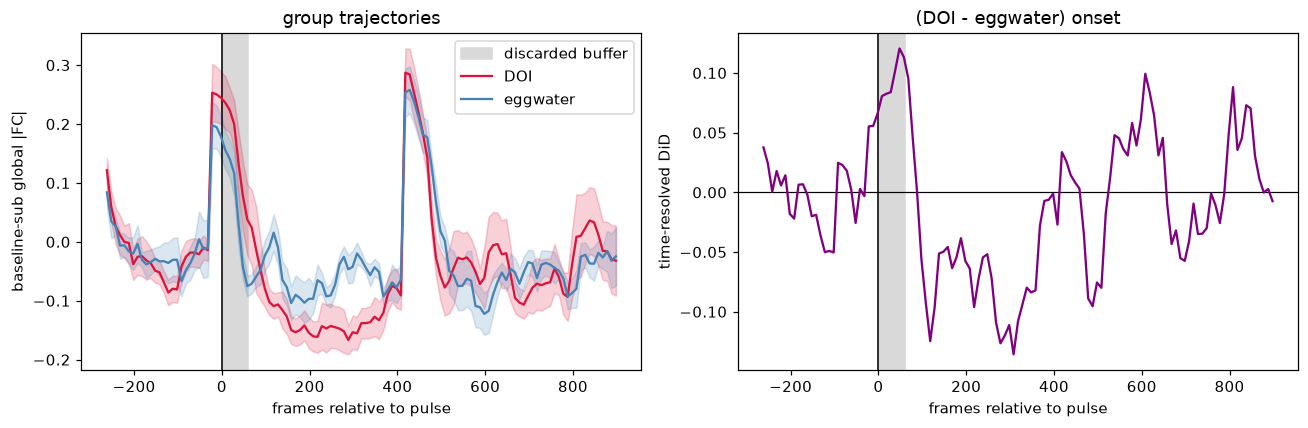

In [25]:
def region_matrix_full(g, regions, cfg):
    field, rfield = cfg['trace_field'], cfg['region_field']
    T = len(g[field].iloc[0]); out = []
    for reg in regions:
        subr = g[g[rfield]==reg]
        if len(subr) < cfg['min_neurons_per_region']:
            out.append(np.full(T, np.nan)); continue
        traces = np.vstack([np.asarray(t,float) for t in subr[field].values])
        out.append(preprocess_trace(np.nanmean(traces,axis=0), cfg))
    return np.vstack(out)

def fc_strength_trajectory(Mfull, cfg):
    n, T = Mfull.shape; centers=[]; vals=[]
    for s in range(0, T-cfg['win_len']+1, cfg['win_step']):
        C = pearson_fc(Mfull[:, s:s+cfg['win_len']])
        iu = np.triu_indices(n,1); off = C[iu]; off = off[np.isfinite(off)]
        centers.append(s + cfg['win_len']//2)
        vals.append(np.nanmean(np.abs(off)) if off.size else np.nan)
    return np.array(centers), np.array(vals)

traj = {}   # fid -> (t_rel, values, group)
for fid in base['fish_id'].unique():
    ep, g = epoch_slices(fid)
    if ep is None: continue
    pf = g['pulse_frames'].iloc[0]; pulse = int(pf[0])
    c, v = fc_strength_trajectory(region_matrix_full(g, REGION_SET, CFG), CFG)
    traj[fid] = (c - pulse, v, g['group'].iloc[0])

# common grid relative to pulse, interpolate each fish, average within group
tmin = max(min(tr[0].min() for tr in traj.values()), -600)
tmax = min(min(tr[0].max() for tr in traj.values()),  900)
grid = np.arange(tmin, tmax, CFG['win_step'])
def group_curve(grp):
    stack = [np.interp(grid, tr[0], tr[1]) for tr in traj.values() if tr[2]==grp]
    A = np.vstack(stack); base_mask = grid < -CFG['pre_buffer_frames']
    A = A - A[:, base_mask].mean(axis=1, keepdims=True)   # baseline-subtract per fish
    return A.mean(0), A.std(0)/np.sqrt(A.shape[0])
doi_m, doi_e = group_curve('DOI'); egg_m, egg_e = group_curve('eggwater')

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].axvspan(0, CFG['post_buffer_frames'], color='0.85', label='discarded buffer')
ax[0].axvline(0, color='k', lw=1)
ax[0].plot(grid, doi_m, color='crimson', label='DOI'); ax[0].fill_between(grid, doi_m-doi_e, doi_m+doi_e, color='crimson', alpha=.2)
ax[0].plot(grid, egg_m, color='steelblue', label='eggwater'); ax[0].fill_between(grid, egg_m-egg_e, egg_m+egg_e, color='steelblue', alpha=.2)
ax[0].set_xlabel('frames relative to pulse'); ax[0].set_ylabel('baseline-sub global |FC|'); ax[0].legend(); ax[0].set_title('group trajectories')
ax[1].axvspan(0, CFG['post_buffer_frames'], color='0.85'); ax[1].axhline(0, color='k', lw=.8); ax[1].axvline(0, color='k', lw=1)
ax[1].plot(grid, doi_m-egg_m, color='purple'); ax[1].set_xlabel('frames relative to pulse')
ax[1].set_ylabel('time-resolved DiD'); ax[1].set_title('(DOI - eggwater) onset')
plt.tight_layout(); plt.show()


## 18. Effective dimensionality (threshold-free)

Psychedelics predict a **flatter covariance eigenspectrum** — activity spreads over more
dimensions, less dominated by a few global modes. The participation ratio

$$\text{PR} = \frac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2}$$

of the covariance spectrum is a clean scalar with **no threshold parameter**, so it
sidesteps the density-matching machinery entirely. We compute it at both the region scale
(from `MATS`) and the neuron scale (from `NEURON_MATS`), and DiD each.

In [26]:
def participation_ratio(M):
    ok = ~np.all(np.isnan(M), axis=1)
    X = M[ok]
    if X.shape[0] < 2: return np.nan
    lam = np.linalg.eigvalsh(np.cov(X))
    lam = lam[lam > 0]
    if lam.size == 0: return np.nan
    return (lam.sum()**2) / np.sum(lam**2)

pr_rows = []
for (fid,epoch), d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    pr_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                        pr_region=participation_ratio(d['M']),
                        pr_neuron=participation_ratio(NEURON_MATS[(fid,epoch)])))
PR = pd.DataFrame(pr_rows)
print(PR.pivot_table(['pr_region','pr_neuron'], ['fish_id','group'], 'epoch').round(2), "\n")
for m in ['pr_region','pr_neuron']:
    obs,p,_ = perm_test_did(PR, m, CFG['n_perm'], RNG)
    print(f"{m:12s}  ΔΔ = {obs:+.3f}   perm p = {p:.4f}   (positive = DOI raises dimensionality)")


                 pr_neuron        pr_region      
epoch                 post    pre      post   pre
fish_id group                                    
7       eggwater     80.74  50.34      9.64  4.86
8       eggwater     60.19  55.26      5.52  5.35
9       eggwater    163.52  37.30     15.38  6.96
10      eggwater     60.01  42.05      4.02  3.24
11      eggwater    101.59  36.23      8.78  3.50
13      DOI         129.85  51.75     14.87  3.67
15      DOI          95.74  57.55     13.80  5.10
17      DOI          96.83  59.68     13.36  6.58
20      eggwater     55.17  32.03      5.05  3.56
21      eggwater     81.91  63.30      8.44  4.73
24      eggwater     56.78  48.74      6.03  7.02
28      DOI         104.17  48.36     12.59  4.58
30      DOI         135.89  72.32     15.11  6.04
31      DOI         125.64  38.84      7.44  3.99
32      DOI          86.51  58.11      7.47  6.64 

pr_region     ΔΔ = +3.904   perm p = 0.0435   (positive = DOI raises dimensionality)
pr_neuron    

## 19. Criticality — neuronal avalanches & branching ratio

"Psychedelics push cortex toward the critical point" is a live hypothesis, and single-cell
resolution is ideal for testing it. On the z-scored region traces we threshold events
(|z| > `event_z`), form the population activity a(t) = #active regions, cut it into
**avalanches** between quiescent frames, and estimate the **branching ratio** σ = mean
ratio of descendant to ancestor activity. σ ≈ 1 is critical, < 1 subcritical, > 1
supercritical. We DiD σ and the mean avalanche size.

> **Caveat:** the calcium indicator's slow kernel inflates temporal autocorrelation and
> biases σ upward. Read the *DiD* of σ (vehicle-subtracted), not its absolute value, and
> rerun with `trace_field='norm_temporal'` (deconvolved) as the robustness pass.

In [27]:
def avalanche_stats(M, event_z=2.0):
    ok = ~np.all(np.isnan(M), axis=1)
    X = M[ok]
    if X.shape[0] < 3: return np.nan, np.nan
    E = (np.abs(X) > event_z).astype(float)   # region x time event raster
    a = E.sum(axis=0)                           # population activity per frame
    active = a > 0
    # branching ratio: descendants/ancestors across consecutive active frames
    ratios = []
    for t in range(len(a)-1):
        if a[t] > 0 and active[t]:
            ratios.append(a[t+1] / a[t])
    sigma = np.mean(ratios) if ratios else np.nan
    # avalanche sizes = summed activity in each run of active frames
    sizes = []; run = 0
    for t in range(len(a)):
        if active[t]:
            run += a[t]
        elif run > 0:
            sizes.append(run); run = 0
    if run > 0: sizes.append(run)
    return sigma, (np.mean(sizes) if sizes else np.nan)

av_rows = []
for (fid,epoch), d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    sig, sz = avalanche_stats(d['M'])
    av_rows.append(dict(fish_id=fid, group=grp, epoch=epoch, branching=sig, aval_size=sz))
AVAL = pd.DataFrame(av_rows)
print(AVAL.pivot_table(['branching','aval_size'], ['fish_id','group'], 'epoch').round(3), "\n")
for m in ['branching','aval_size']:
    obs,p,_ = perm_test_did(AVAL, m, CFG['n_perm'], RNG)
    print(f"{m:12s}  ΔΔ = {obs:+.4f}   perm p = {p:.4f}   (branching toward 1 = toward criticality)")


                 aval_size         branching       
epoch                 post     pre      post    pre
fish_id group                                      
7       eggwater     8.059  10.000     0.976  0.783
8       eggwater    11.195  12.049     0.842  0.902
9       eggwater     8.000  12.705     0.896  0.787
10      eggwater    16.903  16.250     0.790  0.625
11      eggwater     7.632   8.796     0.812  0.626
13      DOI         10.690   9.809     0.987  0.667
15      DOI          9.571  10.800     0.899  0.687
17      DOI          7.439  10.568     0.838  0.814
20      eggwater     9.837  14.382     0.898  0.702
21      eggwater     7.373  12.882     0.903  0.859
24      eggwater    17.364  13.763     1.131  0.967
28      DOI          8.351  10.104     0.895  0.839
30      DOI          6.623   8.377     0.785  0.686
31      DOI          6.625   9.917     1.014  0.794
32      DOI          8.917   8.310     0.931  0.745 

branching     ΔΔ = +0.0353   perm p = 0.4898   (branching towa

## 20. Metastability (synchrony repertoire)

Increased metastability — the brain visiting a wider range of synchronization states — is
a robust psychedelic signature. Hilbert-transform each region trace to a phase, take the
Kuramoto order parameter R(t) = |⟨e^{iφ}⟩| over regions, and read out:

- **metastability** = SD of R(t) over time (breadth of the synchrony repertoire),
- **mean synchrony** = ⟨R(t)⟩ (the overall coherence level).

DiD both — the interesting psychedelic prediction is *metastability up* (more state
switching) even if mean synchrony is unchanged.

In [28]:
def kuramoto_metastability(M):
    ok = ~np.all(np.isnan(M), axis=1)
    X = M[ok]
    if X.shape[0] < 2: return np.nan, np.nan
    phase = np.angle(signal.hilbert(X, axis=1))
    R = np.abs(np.mean(np.exp(1j*phase), axis=0))
    return np.std(R), np.mean(R)

meta_rows = []
for (fid,epoch), d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    ms, sy = kuramoto_metastability(d['M'])
    meta_rows.append(dict(fish_id=fid, group=grp, epoch=epoch, metastability=ms, synchrony=sy))
META = pd.DataFrame(meta_rows)
print(META.pivot_table(['metastability','synchrony'], ['fish_id','group'], 'epoch').round(3), "\n")
for m in ['metastability','synchrony']:
    obs,p,_ = perm_test_did(META, m, CFG['n_perm'], RNG)
    print(f"{m:14s}  ΔΔ = {obs:+.4f}   perm p = {p:.4f}   (metastability up = wider repertoire)")


                 metastability        synchrony       
epoch                     post    pre      post    pre
fish_id group                                         
7       eggwater         0.140  0.176     0.331  0.491
8       eggwater         0.160  0.192     0.522  0.517
9       eggwater         0.101  0.107     0.193  0.406
10      eggwater         0.156  0.139     0.543  0.610
11      eggwater         0.161  0.121     0.390  0.623
13      DOI              0.117  0.128     0.227  0.617
15      DOI              0.119  0.176     0.275  0.520
17      DOI              0.128  0.171     0.293  0.431
20      eggwater         0.177  0.177     0.492  0.599
21      eggwater         0.160  0.195     0.380  0.501
24      eggwater         0.129  0.174     0.374  0.351
28      DOI              0.148  0.171     0.308  0.561
30      DOI              0.136  0.161     0.279  0.449
31      DOI              0.149  0.176     0.436  0.550
32      DOI              0.194  0.109     0.379  0.486 

metastab

## 21. Structure–function decoupling

A canonical psychedelic finding is that **function is liberated from anatomy** — the
FC–SC correlation drops, so activity is less constrained by the wiring. We measure the
per-fish/epoch coupling as the Spearman correlation between the FC edges and the
structural edges, then DiD it (the prediction: DOI *lowers* coupling).

> **No real connectome? A distance proxy runs the plumbing.** With `SC_PATH=None` we use
> an exponential-distance structural prior SC_ij = exp(−d_ij/d0) — a decent first-order
> stand-in (short-range regions are more likely wired). Point `SC_PATH` at a mapZebrain
> region×region structural matrix (aligned to `REGION_SET`) for the real test; the proxy
> result should be read as methodological, not biological.

In [29]:
SC_PATH = None   # e.g. Path('.../mapzebrain_region_SC.npy'), aligned to REGION_SET order

def structural_matrix(regions, dist, idx):
    if SC_PATH and Path(SC_PATH).is_file():
        SC = np.load(str(SC_PATH))
        return SC, True
    d0 = np.median(dist[dist>0]); SC = np.exp(-dist/d0); np.fill_diagonal(SC, 0.0)
    return SC, False

# reuse the distance matrix DIST / idx from Sec 14 (regions with centroids)
SC, sc_real = structural_matrix(REGION_SET, DIST, idx)
iu_sc = np.triu_indices(SC.shape[0], 1); sc_edges = SC[iu_sc]

def scfc_coupling(A_full, idx, sc_edges, iu_sc):
    F = np.abs(A_full[np.ix_(idx, idx)])[iu_sc]
    ok = np.isfinite(F) & np.isfinite(sc_edges) & (F+sc_edges > 0)
    if ok.sum() < 5: return np.nan
    return ss.spearmanr(F[ok], sc_edges[ok]).correlation

sf_rows = []
for (fid,epoch), d in MATS.items():
    grp = RESULTS[RESULTS.fish_id==fid]['group'].iloc[0]
    sf_rows.append(dict(fish_id=fid, group=grp, epoch=epoch,
                        scfc=scfc_coupling(d['A'], idx, sc_edges, iu_sc)))
SCFC = pd.DataFrame(sf_rows)
print(SCFC.pivot_table('scfc', ['fish_id','group'], 'epoch').round(3), "\n")
obs,p,_ = perm_test_did(SCFC, 'scfc', CFG['n_perm'], RNG)
print(f"SC-FC coupling ΔΔ = {obs:+.4f}   perm p = {p:.4f}",
      "(negative = DOI decouples function from structure)",
      "" if sc_real else "\n   << distance-proxy structural prior; set SC_PATH for the real connectome")


epoch              post    pre
fish_id group                 
7       eggwater  0.123  0.183
8       eggwater  0.132  0.226
9       eggwater  0.242  0.228
10      eggwater  0.174  0.152
11      eggwater  0.170  0.299
13      DOI       0.042  0.215
15      DOI       0.018  0.197
17      DOI       0.223  0.193
20      eggwater  0.151  0.156
21      eggwater  0.111  0.212
24      eggwater  0.078  0.132
28      DOI       0.142  0.256
30      DOI       0.087  0.118
31      DOI       0.147  0.154
32      DOI       0.207  0.160 

SC-FC coupling ΔΔ = -0.0102   perm p = 0.8076 (negative = DOI decouples function from structure) 
   << distance-proxy structural prior; set SC_PATH for the real connectome


## Next steps

You now have the full DiD scaffold end-to-end. Concrete order of attack:

1. **Lock the milestone (Sec 1–8).** Confirm the sign of the modularity / efficiency
   interaction and that it survives the density sweep and permutation test.
2. **Tune the epoch buffer** (`post_buffer_frames`) to your frame rate and DOI onset —
   look at the dynamic-FC plot (Sec 9) to see where the effect actually starts.
3. **Second estimator:** rerun with `CFG['fc_method']='partial'` and confirm the
   headline result holds (guards against a global-arousal confound).
4. **Cellular scale (Sec 16):** the neuron-level distribution FC gives a cellular-
   resolution view your fMRI-based references can't offer — cross-check it against the
   region-level headline.
5. **Structural connectome (Sec 21):** swap the distance proxy for a real mapZebrain
   region×region SC matrix (`SC_PATH`) to make the decoupling test biological.

Every metric flows through `did_value()` + `perm_test_did()`, so adding a new readout is
just: compute it per (fish, epoch) → a tidy DataFrame with `fish_id/group/epoch` → those
two functions.